In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from smooth_POD_ROM.reduced_order_model import pulse, delta_n_width
from smooth_POD_ROM.pre_processing import gaussian, gaussian_f, convolve_f
from scipy.ndimage import gaussian_filter
cmap = plt.cm.plasma

In [11]:
page_width_pt = 455.24
pt2in = 0.01389
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"
markevery = 45

8.030570172000001


In [12]:
m, n = 2500, 2500
# w = 30  # width of the pulse in # nodes
x = np.linspace(0, 1, m, endpoint=False)+1/(2*m)
mu_train = np.linspace(0.0, 1.0, n, endpoint=False)+1/(2*n)
# mu_test = np.array([0.2, 0.22, 0.225, 0.23,  0.24, 0.25])
# mu_validation = np.linspace(0, 1, m, endpoint=False)
sigma = 0.05
mode = "constant"
rank = 10
dx = 1/m
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"


X_train = np.empty((m, len(mu_train)))
X_train_s1 = np.empty((m, len(mu_train)))
X_train_s2 = np.empty((m, len(mu_train)))
X_train_s3 = np.empty((m, len(mu_train)))
X_train_s4 = np.empty((m, len(mu_train)))
X_train_s5 = np.empty((m, len(mu_train)))


def test1():
    sigma = 0.05
    mu = 0.25
    x = np.linspace(0, 1, 101, endpoint=False)
    dx = x[1]-x[0]
    y = pulse(x, mu)
    g_x = gaussian(x-0.5+dx, sigma, shift=False)
    g_f = gaussian_f(x, sigma)
    ys1 = convolve_f(y, g_f)
    # ! boundary effects cant be avoided!
    ys2 = np.convolve(y, g_x, mode="same")
    ys3 = gaussian_filter(y, sigma=sigma/dx, truncate=12, mode="wrap")
    print(np.allclose(ys1, ys2, atol=1e-6))
    print(np.allclose(ys1, ys3, atol=1e-6))
    print(np.allclose(ys2, ys3, atol=1e-6))
    plt.plot(x, y, "C0.")
    plt.plot(x, ys1, "C1.")
    plt.plot(x, ys2, "C2.")
    plt.plot(x, ys3, "C3.")
    return

In [20]:
n1 = int(0.05*m)
ma1 = np.ones(n1,)/n1

for j, mu_j in enumerate(mu_train):
    y = pulse(x, mu_j, w=0.075-1e-6)
    X_train[:, j] = y
    X_train_s1[:, j] = gaussian_filter(y, sigma=0.005/dx, truncate=12, mode="wrap")
    X_train_s2[:, j] = gaussian_filter(y, sigma=0.01/dx, truncate=12, mode="wrap")
    X_train_s3[:, j] = np.convolve(y, ma1, mode="same")

U1, S1, VT = np.linalg.svd(X_train, False)
U2, S2, VT = np.linalg.svd(X_train_s1, False)
U3, S3, VT = np.linalg.svd(X_train_s2, False)
U4, S4, VT = np.linalg.svd(X_train_s3, False)
delta_N1 = delta_n_width(S1, m, n)
delta_N2 = delta_n_width(S2, m, n)
delta_N3 = delta_n_width(S3, m, n)
delta_N4 = delta_n_width(S4, m, n)

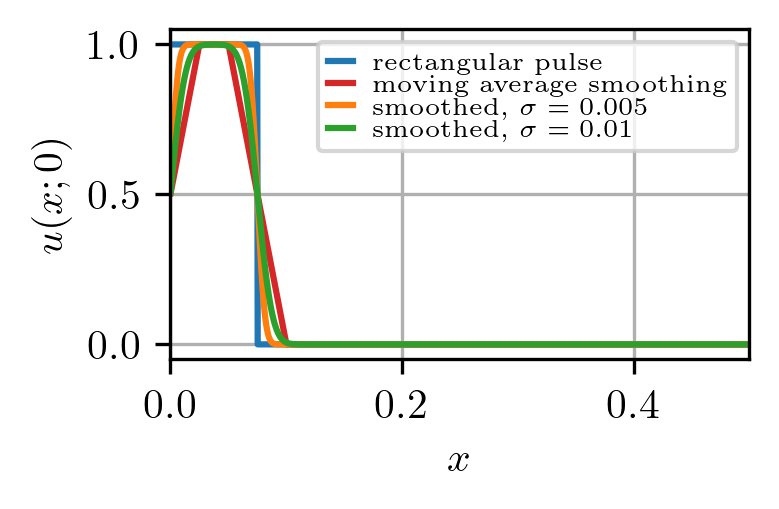

C:\Users\florianma\AppData\Local\Temp\ipykernel_29032\3111332649.py:19: RuntimeWarning: divide by zero encountered in power
  plt.plot(delta_N1 / (1/np.pi*np.arange(len(S1))**(-1/2)), ".")


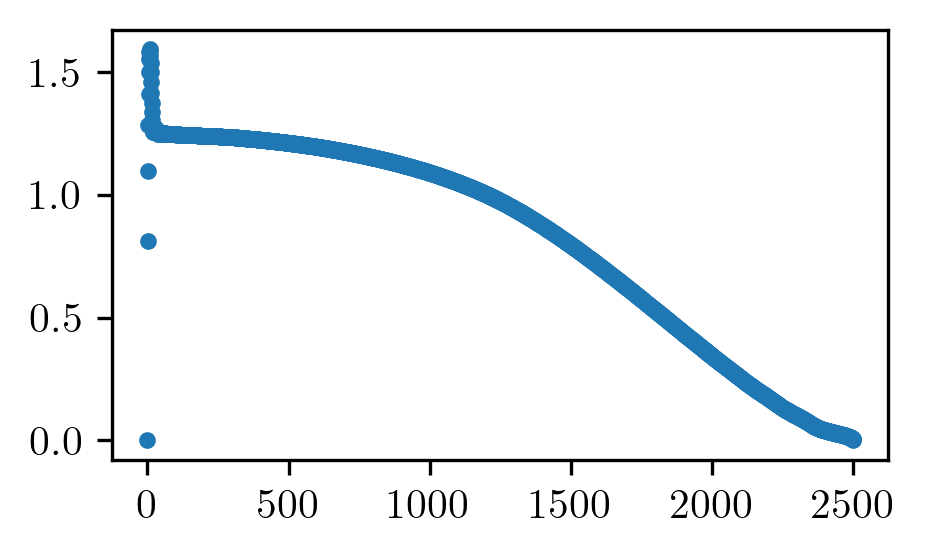

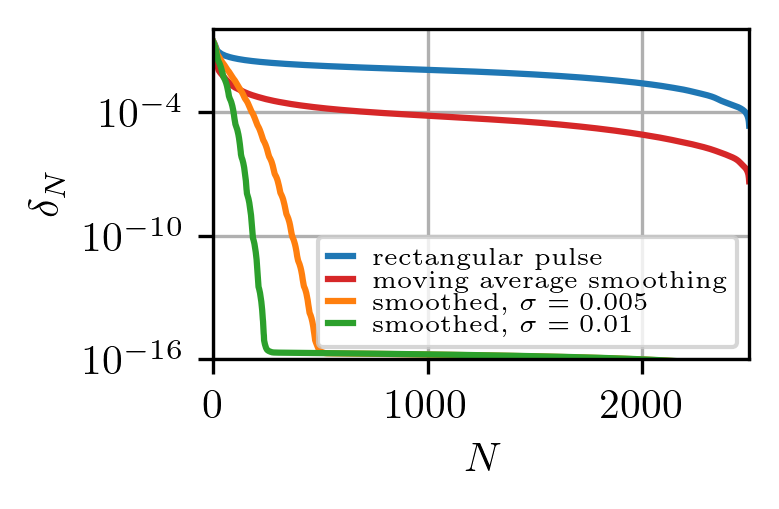

In [22]:
nss = 0
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(x, X_train[:, nss], "C0-", label="rectangular pulse")
ax.plot(x, X_train_s3[:, nss], "C3-", label="moving average smoothing")
ax.plot(x, X_train_s1[:, nss], "C1-", label="smoothed, $\sigma=0.005$")
ax.plot(x, X_train_s2[:, nss], "C2-", label="smoothed, $\sigma=0.01$")
plt.grid(which="minor")
plt.grid(which="major")
ax.set_xlim([0.0, .5])
ax.set_ylim([-0.05, 1.05])
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x; 0)$")
plt.legend()
plt.tight_layout()
plt.savefig(pth+"Pulse_smoothing.pdf")
plt.show()

fig, ax = plt.subplots()
plt.plot(delta_N1 / (1/np.pi*np.arange(len(S1))**(-1/2)), ".")
plt.show()

fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(delta_N1, "C0-", ms=1, label="rectangular pulse")
ax.plot(delta_N4, "C3-", ms=1, label="moving average smoothing")
ax.plot(delta_N2, "C1-", ms=1, label="smoothed, $\sigma=0.005$")
ax.plot(delta_N3, "C2-", ms=1, label="smoothed, $\sigma=0.01$")
# ax.plot(1/np.pi*np.arange(len(S))**(-1/2), "k--")
ax.set_yscale('log')
ax.set_xlim([0, len(S1)])
ax.set_ylim([1e-16, 1])
plt.grid(which="minor")
plt.grid(which="major")
ax.set_xlabel("$N$")
ax.set_ylabel("$\delta_N$")
plt.legend()
plt.tight_layout()
plt.savefig(pth+"Pulse_smoothing_deltaN.pdf")
plt.show()

In [5]:
# def pulseHWS(x, mu, w=0.1+1e-6):
#     y = np.zeros_like(x, dtype=np.float64)
#     y[((0+1e-6) < (x-mu)) & ((x-mu) < (w-1e-6))] = 1.0
#     mu2 = mu+1
#     y[((0+1e-6) < (x-mu2)) & ((x-mu2) < (w-1e-6))] = -1.0
#     mu3 = mu-1
#     y[((0+1e-6) < (x-mu3)) & ((x-mu3) < (w-1e-6))] = -1.0
#     mu4 = mu-2
#     y[((0+1e-6) < (x-mu4)) & ((x-mu4) < (w-1e-6))] = 1.0
#     return y

# from smooth_POD_ROM.pre_processing import smoothen
# from smooth_POD_ROM.reduced_order_model import pulse, delta_n_width

In [6]:
0.05/dx

125.0

125.0

0.0002 0.9998
1.0002 1.0002
mu
0.05 0.9500000000000001
0.05 1.0499999999999998
20
[15.8113883 15.8113883 15.8113883 15.8113883 15.8113883 15.8113883]
[15.59121898 14.81651059 13.91468209 12.1859826  11.00324746  8.79225074]
0.0002 0.9998
1.0002 1.0002
mu
0.03333333333333333 0.9666666666666667
0.03333333333333333 1.0333333333333332
30
[20.3268412  20.07141945 19.65027403 19.07018653 18.32974573 17.48153618]
[19.11651242 18.13755915 17.19362242 14.89354544 13.75362172 10.70100821]
0.0002 0.9998
1.0002 1.0002
mu
0.02 0.98
0.02 1.02
50
0.0002 0.9998
1.0002 1.0002
mu
0.05 0.9500000000000001
0.05 1.0499999999999998
20
[15.8113883 15.8113883 15.8113883 15.8113883 15.8113883 15.8113883]
[15.59121898 14.81651059 13.91468209 12.1859826  11.00324746  8.79225074]
0.0002 0.9998
1.0002 1.0002
mu
0.03333333333333333 0.9666666666666667
0.03333333333333333 1.0333333333333332
30
[20.3268412  20.07141945 19.65027403 19.07018653 18.32974573 17.48153618]
[19.11651242 18.13755915 17.19362242 14.89354544 13.

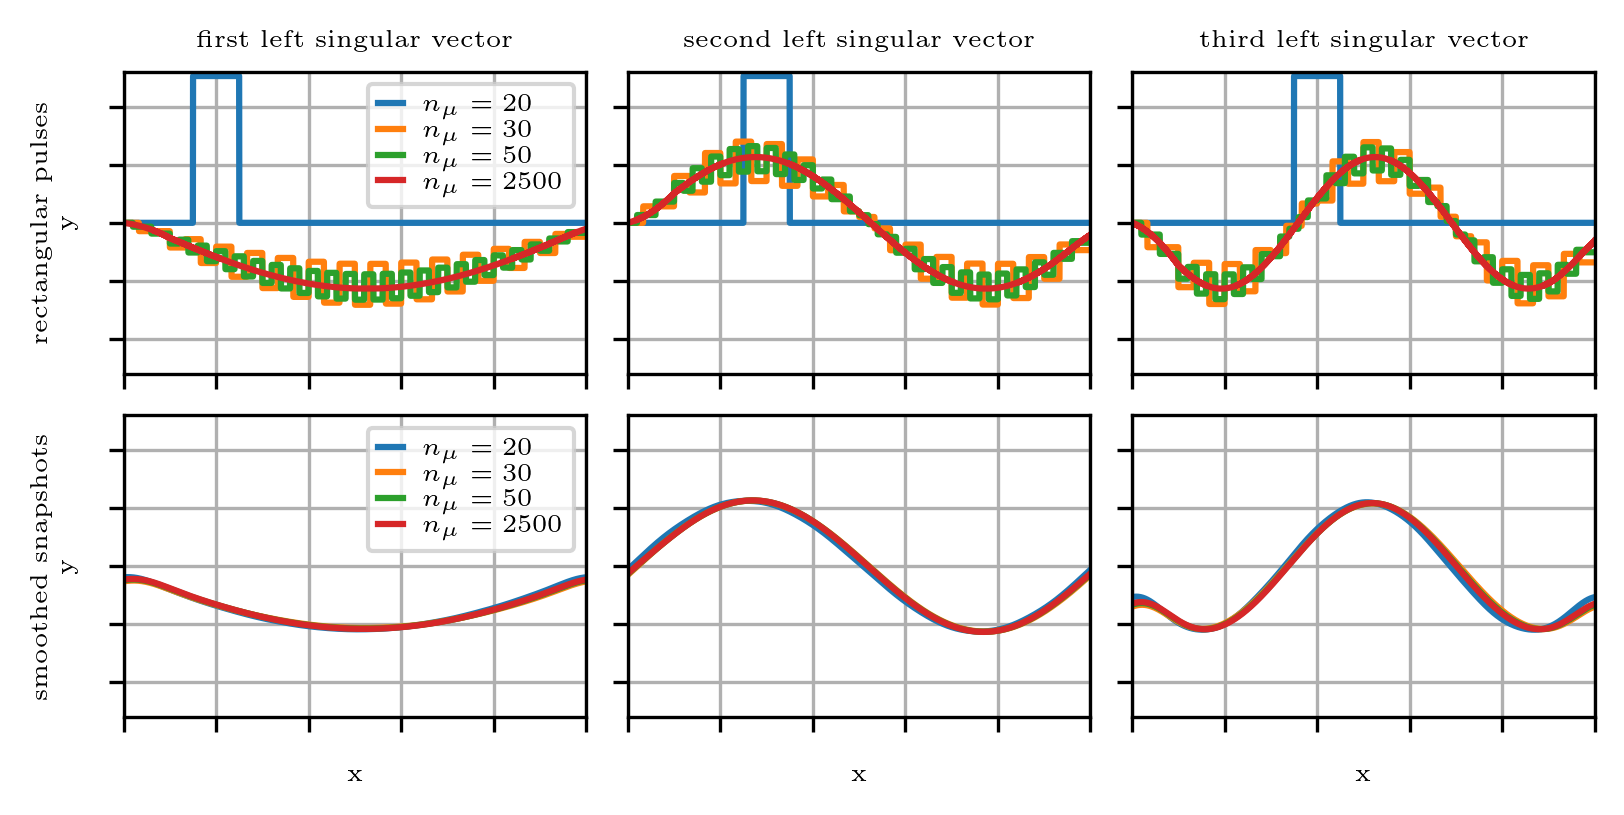

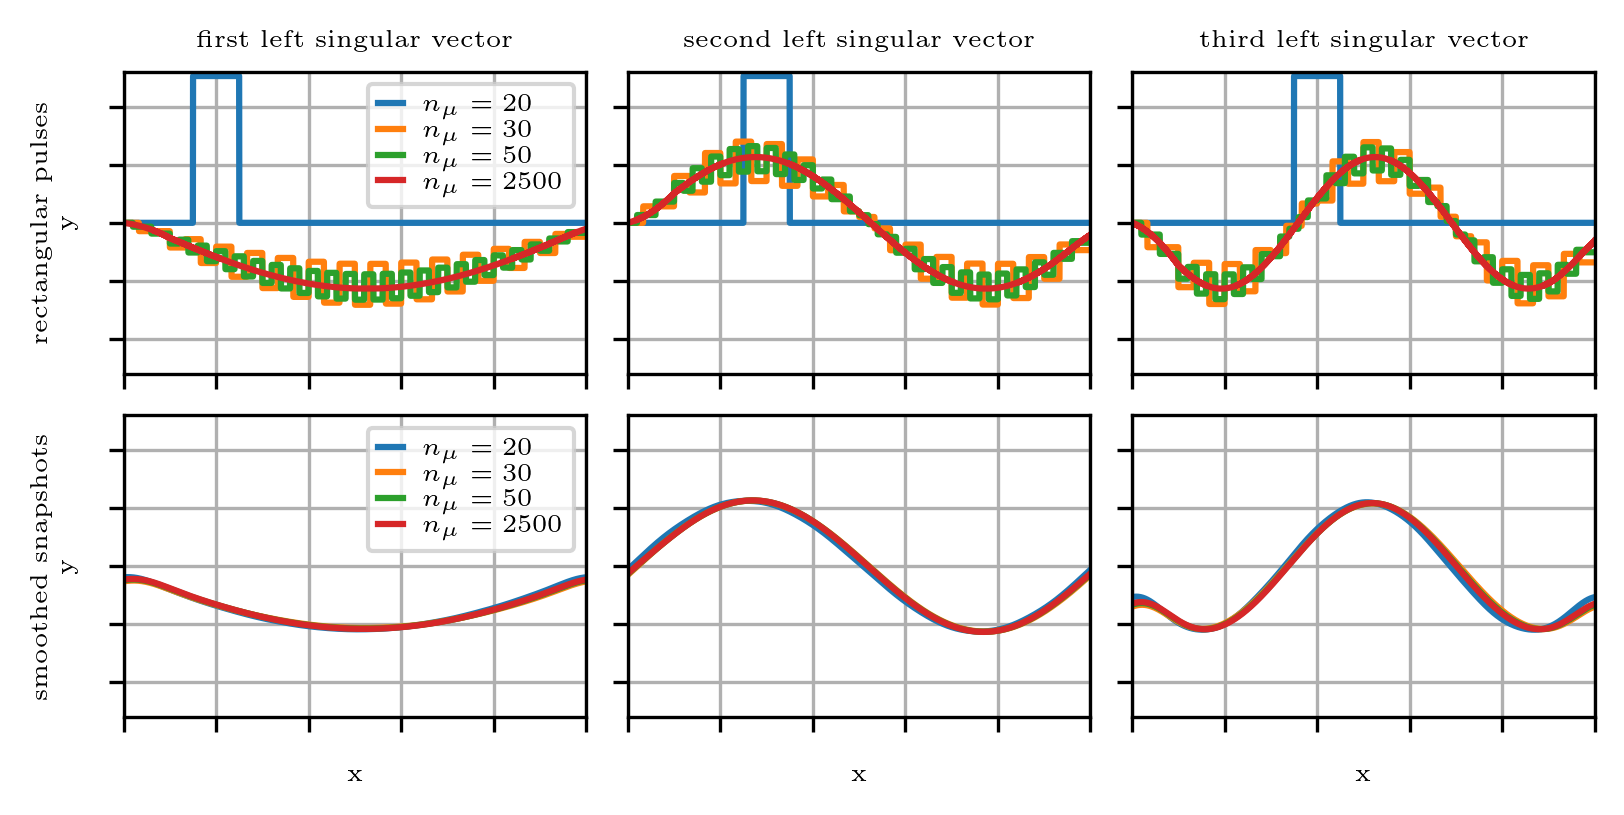

In [21]:
# m = 600
HWS = False
fig, axs = plt.subplots(2, 3, figsize=(page_width_in, page_width_in/2))
i = 0
for n in [20, 30, 50, m]:
    x = np.linspace(0, 1, m, endpoint=False) + 1/2*(1/m)
    mu = np.linspace(0, 1, n//2, endpoint=False) + 1/2*(2/n)
    print(x[0], x[-1])
    print(x[0]-(-1), 2-x[-1])
    print("mu")
    print(mu[0], mu[-1])
    print(mu[0], 2-mu[-1])
    print(n)
    
    X = np.zeros((m, n//2))
    Xs = np.zeros((m, n//2))
    for j, mu_j in enumerate(mu):
        y = pulse(x, mu_j, w=0.1-1e-6)
        Xs[:, j] = gaussian_filter(y, sigma=0.05/dx, truncate=12, mode="wrap")  # 0.05 or 0.005
        X[:, j] = y

    dx = 1/m
    Ug, Sg, Vg = np.linalg.svd(X, full_matrices=False)
    Us, Ss, Vs = np.linalg.svd(Xs, full_matrices=False)
    print(Sg[:6])
    print(Ss[:6])

    Ug[:, np.mean(Ug[m//2:, :], axis=0)>=0] *= -1
    Us[:, np.mean(Us[m//2:, :], axis=0)>=0] *= -1
    for j in range(3):
        axs[0, j].plot(x, Ug[:, j], "C"+str(i)+"-", ms=1, label="$n_{\mu}=%i$"%n)
        axs[1, j].plot(x, Us[:, j], "C"+str(i)+"-", ms=1, label="$n_{\mu}=%i$"%n)
    i += 1
for i, ax in enumerate(axs.ravel()):
    #ax.set_xticks(np.linspace(-1., 1., 21, endpoint=True), minor=True)
    #ax.set_yticks(np.linspace(-.2, .2, 21, endpoint=True), minor=True)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(False, which='minor')
    ax.grid(True, which='major', linestyle='-')
    ax.set_xlim(-0.0, 1.0)
    ax.set_ylim(-0.065, 0.065)
axs[0, 0].legend()
axs[1, 0].legend()

axs[0, 0].set_ylabel("rectangular pulses \n y")
axs[1, 0].set_ylabel("smoothed snapshots \n y")
axs[1, 0].set_xlabel("x")
axs[1, 1].set_xlabel("x")
axs[1, 2].set_xlabel("x")

axs[0, 0].set_title("first left singular vector")
axs[0, 1].set_title("second left singular vector")
axs[0, 2].set_title("third left singular vector")
plt.savefig(pth+"leftSV.pdf")
plt.show()

In [8]:
np.sum(X, axis=0)

array([250., 250., 250., ...,   5.,   3.,   1.])

array([250., 250., 250., ...,   5.,   3.,   1.])